# Figure S7 — Facilitation vs Pulse Number (125 nm ER–PM distance)

Facilitation across a 20-pulse 20 Hz train for Control, AD + 5× RyR, and AD + 1/2× RyR at an ER–PM distance of 125 nm. Compare with Fig. 6i (15 nm standard distance).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plot_config.py lives in the same figures/ directory
sys.path.insert(0, str(Path(".").resolve()))
from plot_config import (
    get_condition,
    apply_style,
    strip_spines,
    label_panel,
    set_n_ticks,
    save_figure,
)

apply_style()

In [2]:
# ============================================================
# CONFIG
# ============================================================

DATA_DIRS = {
    "control":     Path("/data/hdrive/phd/results/train/125nm/RSV80C250uM_20_p20hz_8_10_serca_125nm"),
    "ad_5x_ryr":   Path("/data/hdrive/phd/results/train/125nm/RSV80C750uM_20_p20hz_5xryr_8_10xserca_125nm"),
    "ad_half_ryr": Path("/data/hdrive/phd/results/train/125nm/RSV80C750uM_20_p20hz_8_10_serca_1_2xryr_125nm"),
}

N_PULSES = 20

FIGSIZE   = (6, 3.5)
SAVE_NAME = "figS7_125nm_facilitation.png"

MARKERSIZE  = 6
CAPSIZE     = 3
ELINEWIDTH  = 1.2

PULSE_XTICKS = [1, N_PULSES // 2, N_PULSES]
FAC_YTICKS   = [0, 3, 6]   # match Fig 6i y-range

In [3]:
# ============================================================
# DATA LOADING
# ============================================================

def load_result(fname):
    """result file: row 0 = means, row 1 = stds, cols [0:20]=Pr, [20:40]=Facilitation."""
    d = np.loadtxt(fname)
    assert d.shape == (2, 40), f"Unexpected shape {d.shape} in {fname}"
    means, stds = d[0], d[1]
    return {
        "fac_mean": means[20:],
        "fac_sd":   stds[20:],
    }

pulses = np.arange(1, N_PULSES + 1)
data = {key: load_result(path / "result") for key, path in DATA_DIRS.items()}

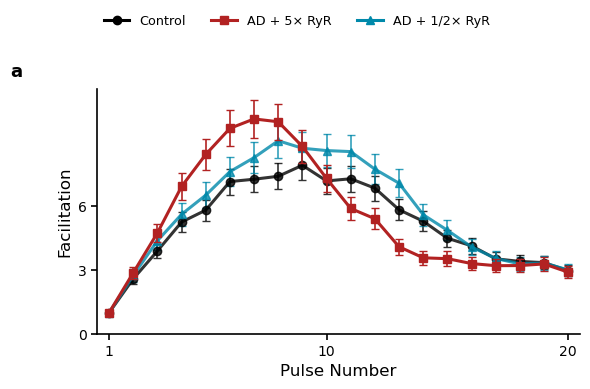

In [4]:
# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE)

for key in DATA_DIRS:
    cond = get_condition(key)
    ax.errorbar(
        pulses,
        data[key]["fac_mean"],
        yerr=data[key]["fac_sd"],
        color=cond.color,
        marker=cond.marker,
        linestyle=cond.linestyle,
        markersize=MARKERSIZE,
        capsize=CAPSIZE,
        elinewidth=ELINEWIDTH,
        alpha=cond.alpha,
        zorder=cond.zorder,
        label=cond.label,
    )

ax.set_xlabel("Pulse Number")
ax.set_ylabel("Facilitation")
ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
ax.set_xticks(PULSE_XTICKS)
ax.set_yticks(FAC_YTICKS)
strip_spines(ax)
label_panel(ax, "a")

condition_handles = [
    Line2D([0], [0],
           color=get_condition(k).color,
           marker=get_condition(k).marker,
           linestyle="-",
           markersize=MARKERSIZE,
           label=get_condition(k).label)
    for k in DATA_DIRS
]
fig.legend(
    handles=condition_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.12),
    fontsize="small",
)

plt.tight_layout()
save_figure(fig, SAVE_NAME)
plt.show()